In [151]:
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy import stats

In [17]:
def binomial_probability(k, n, nu):
    if k > n:
        print("k is larger than n!!")
        print(n, k)
    coeff = (math.factorial(n))/(math.factorial(k)*math.factorial(n-k))
    return coeff*(nu**k)*(1-nu)**(n-k)

[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20]


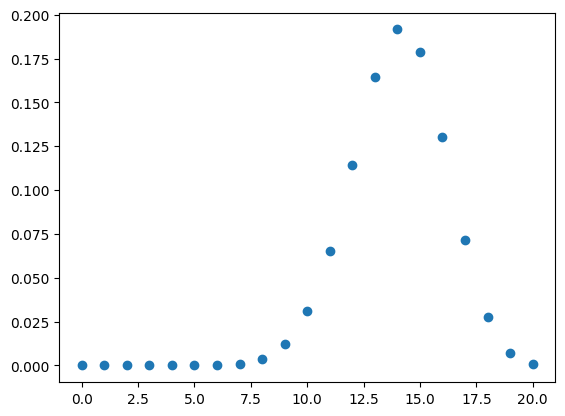

In [7]:
N = 20
nu = 0.7
k_list = np.arange(0, N+1)
print(k_list)
probs = [binomial_probability(k, N, nu) for k in k_list]
plt.scatter(k_list, probs)

Unbiased estimator

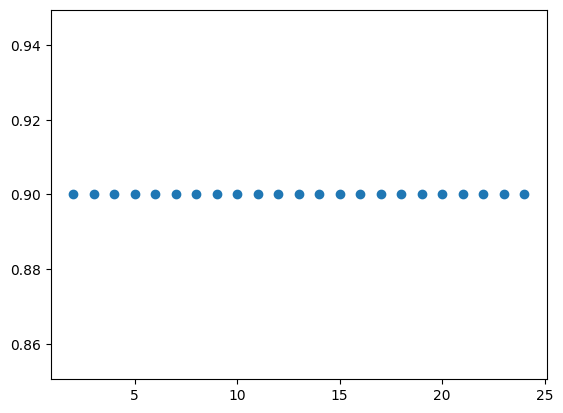

In [22]:
def expected_frequency(n, nu):
    k_list = np.arange(0, n+1)
    expected_value = 0
    for k in k_list:
        frequency = k/n
        prob = binomial_probability(k, n, nu)
        expected_value = expected_value + prob*frequency
    return expected_value

n_list = np.arange(2, 25)
nu=0.9
exp_values = [expected_frequency(n, nu) for n in n_list]
plt.scatter(n_list, exp_values)

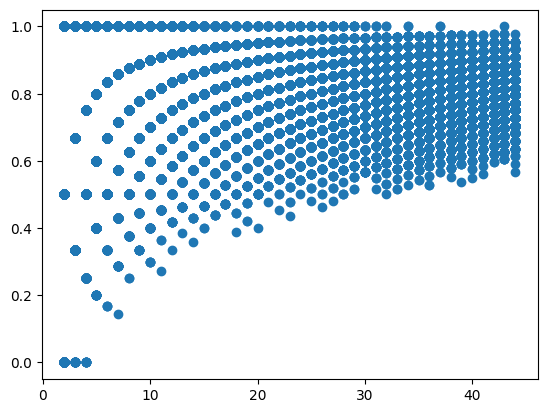

In [167]:
n_list = np.arange(2, 45)
nu=0.8
M=3000
frequencies = np.zeros((M, len(n_list)))
for m in range(0,M):
    k_list = [np.random.binomial(n, nu) for n in n_list]
    frequencies[m] = [k_list[i]/n_list[i] for i in range(len(n_list))]
f_mean = frequencies.mean(axis=0)
err_up = np.percentile(frequencies, 95, axis=0)
err_down = np.percentile(frequencies, 35, axis=0)

plt.scatter([n_list]*M, frequencies, alpha=1)
#plt.errorbar(n_list, f_mean, yerr=(err_down, err_up))


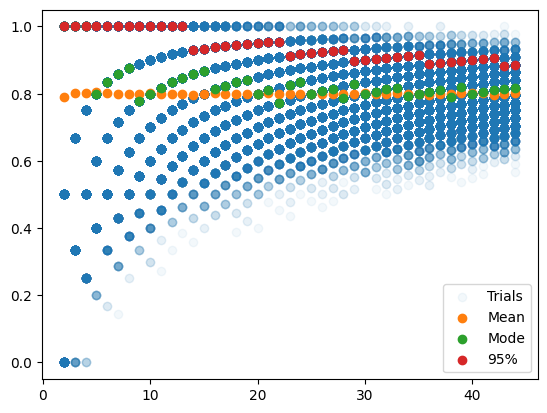

In [173]:
fig, ax = plt.subplots()
ax.scatter([n_list]*M, frequencies, alpha=0.05, label="Trials")
ax.scatter(n_list, f_mean, label="Mean")
ax.scatter(n_list, stats.mode(frequencies, axis=0)[0], label="Mode")
ax.scatter(n_list, err_up, label="95%")
ax.legend()

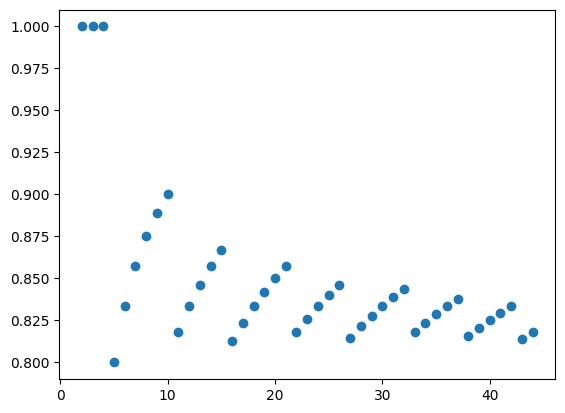

In [166]:
plt.scatter(n_list, err_up)

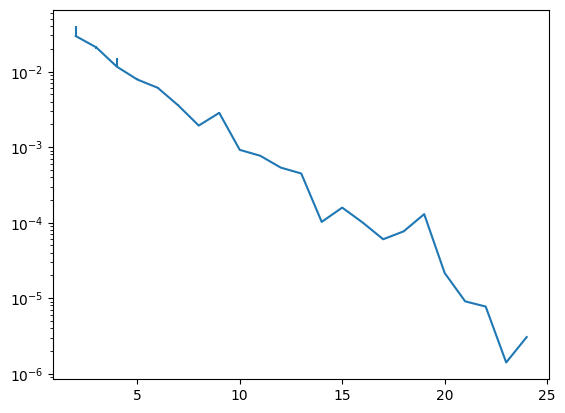

In [132]:
def p_value(k, n, nu):
    p = 0
    for i in range(0, k):
        p = p + binomial_probability(i, n, nu)
    return p

n_list = np.arange(2, 25)
nu_exp=0.9
nu_true=0.36
M = 1000
p_values = np.zeros((M, len(n_list)))

for m in range(0,M):
    k_list = [np.random.binomial(n, nu_true) for n in n_list]
    p_values[m] = [p_value(k_list[i], n_list[i], nu_exp) for i in range(len(n_list))]
    mean = p_values[m].mean()
p_mean = p_values.mean(axis=0)
err_up = np.percentile(p_values, 65, axis=0)
err_down = np.percentile(p_values, 35, axis=0)

plt.errorbar(n_list, p_mean, yerr=(err_down, err_up))
plt.yscale("log")

[0.18782756 0.17537338 0.1639329  0.15326202 0.1433265  0.13405156
 0.12538906 0.11729722 0.10973764 0.10267478 0.09607549 0.08990887
 0.08414606 0.07876016 0.07372604 0.0690203  0.06462108 0.060508
 0.05666208 0.0530656  0.04970203 0.04655597 0.04361306 0.0408599
 0.03828399 0.03587368 0.03361809 0.03150708 0.02953118 0.02768157
 0.02595    0.02432878 0.02281073 0.02138915 0.02005778 0.01881078
 0.0176427  0.01654843 0.01552323 0.01456264 0.01366251 0.01281897
 0.01202838]


(0.001, 1)

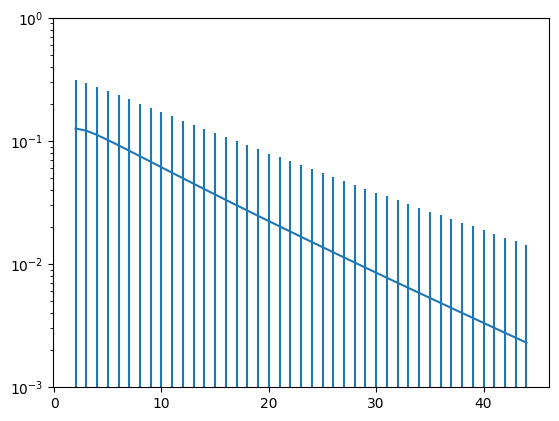

In [134]:
def expected_p_value(n, nu_true, nu_expected):
    exp_value = 0
    variance = 0
    for k in range(0, n+1):
        prob = binomial_probability(k, n, nu_true)
        p = p_value(k, n, nu_expected)
        exp_value = exp_value + prob*p
    for k in range(0, n+1):
        prob = binomial_probability(k, n, nu_true)
        p = p_value(k, n, nu_expected)
        variance = variance + prob*(exp_value-p)**2
    return exp_value, variance

n_list = np.arange(2, 45)
nu_exp=0.49
nu_true = 0.22
p_values = np.zeros(len(n_list))
variances = np.zeros(len(n_list))

for i, n in enumerate(n_list):
    p_values[i], variances[i] = expected_p_value(n, nu_true, nu_exp)
print(np.sqrt(variances))
plt.errorbar(n_list, p_values, yerr=np.sqrt(variances))
plt.yscale("log")
plt.ylim(10**(-3), 1)